# **Introduction to Langchain**

LangChain is a framework facilitates the creation of context-aware applications by integrating language models with various sources of context. Thus, allowing for nuanced responses grounded in prompts, examples, or related content. Furthermore, it empowers applications to utilize language models for reasoning, guiding their responses and actions based on the provided context.

# **Getting Started with Langchain**

Let's install Langchain first

In [ ]:
# !pip install langchain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 6.1 MB/s eta 0:00:00


To use langchain we need to integrate with one or more model providers, datastores, APIs etc. In this example we will use OpenAi's model APIs.

So, let's install **`openai`** package

In [ ]:
# !pip install openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llmx 0.0.15a0 requires cohere, which is not installed.
llmx 0.0.15a0 requires tiktoken, which is not installed.


Accessing the Openai API requires a API key, Once you have a key you can run the cell below and input your key

In [ ]:
import os
import getpass
from dotenv import load_dotenv
load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")

Open AI API Key:··········


In [ ]:
from langchain.llms import OpenAI
llm = OpenAI(temperature = 0.9)
text = "Tell me something about Mount Everest"
print(llm.predict(text))



Mount Everest is the highest mountain on Earth, with an elevation of 8,848 meters (29,029 ft). Located in the Mahalangur Himal sub-range of the Himalayas, it straddles the borders of Nepal and China. It is part of the fourteen eight-thousanders, a group of mountains that are higher than 8,000 meters (26,247 ft) above sea level.


>**Note- The temperature parameter is a measure of randomness in the output of the LLM. Its value ranges from 0-1.When temperature is 0 the output of the LLM is always the same**

There are two types of language models you can use in Langchain,

1. LLMs: this is a language model which takes a string as input and returns a string
2. ChatModels: this is a language model which takes a list of messages as input and returns a message

The above code uses the LLM model lets try out ChatModels next

In [ ]:
from langchain.chat_models import ChatOpenAI

chat_model = ChatOpenAI()
text = "Tell me something about Mount Everest"
print(chat_model.predict(text))

Mount Everest is the highest mountain in the world, with its peak reaching an elevation of 8,848.86 meters (29,031.7 feet) above sea level. It is located in the Mahalangur Himal sub-range of the Himalayas, straddling the border between Nepal and China (Tibet). 

The mountain was named after Sir George Everest, a British surveyor-general of India, who first recorded the location and height of the peak in 1856. However, the local name for the mountain is "Sagarmatha" in Nepal and "Chomolungma" in Tibet, both of which translate to "Goddess Mother of the World."

Mount Everest is a popular destination for mountaineers, attracting climbers from around the globe. The first successful ascent of Everest was accomplished by Sir Edmund Hillary of New Zealand and Tenzing Norgay, a Sherpa of Nepal, on May 29, 1953. Since then, thousands of climbers have attempted to reach the summit, but it remains a challenging and dangerous endeavor, with a significant risk of altitude sickness and extreme weath

The input/output for LLMs is simple and easy to understand - a string. The input there is a list of ChatMessages, and the output is a single ChatMessage. `ChatMessage` has two required components:

`content`: This is the content of the message.

`role`: This is the role of the entity from which the ChatMessage is coming from.

# **Prompt Template**

In the previous example, the text we passed to the model had instructions to generate a response.In some cases, the user might only need to provide the description , without having to worry about giving the model instructions. Prompt Template helps us achieve this. They bundle up all the logic for going from user input into a fully formatted prompt

Lets us look at the code below

## `PromptTemplate`

In [ ]:
from langchain.prompts import PromptTemplate

prompt = PromptTemplate.from_template("Which place is known for its {food}? List it out")
print(prompt.format(food="Wine"))
print(llm(prompt.format(food="Wine")))

Which place is known for its Wine? List it out


1. Bordeaux, France
2. Napa Valley, California, USA
3. Tuscany, Italy
4. Rioja, Spain
5. Hunter Valley, Australia
6. Stellenbosch, South Africa
7. Mosel, Germany
8. Douro Valley, Portugal
9. Marlborough, New Zealand
10. Willamette Valley, Oregon, USA


Let's check out an example with more than one inputs and see how we can start extending this to make more complex prompt

In [ ]:
from langchain.prompts import PromptTemplate
template= """
You are an expert in {programming_language} programming
{query}
"""
multi_input_prompt = PromptTemplate(input_variables= ['programming_language' , 'query'],template =template)
input = multi_input_prompt.format(programming_language = "python", query="Write hello world program")
print(input)
print(llm(input))



You are an expert in python programming
Write hello world program


# Program to print "Hello, World!"
print("Hello, World!")


For additional validation, specify `input_variables` explicitly. These variables will be compared against the variables present in the template string during instantiation, raising an exception if there is a mismatch.

## `ChatPromptTemplate`

Let us look at some more advance example. In this case, the prompt not only contains information about the content, but also each message (its role, its position in the list, etc.). The code below uses **ChatModels**. **LLM** cannot be used without chaining in this method

In [ ]:
from langchain.prompts.chat import ChatPromptTemplate

template = "You are a helpful assistant that translates {input_language} to {output_language}."
human_template = "{text}"
chat_model = ChatOpenAI()
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", template),
    ("human", human_template),
])

print(chat_model(chat_prompt.format_messages(input_language="English", output_language="Spanish", text="People like to travel .")))

content='A la gente le gusta viajar.'


In [ ]:
from langchain.prompts import ChatPromptTemplate

chat_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful AI bot. Your name is {name}."),
        ("human", "Hello, how are you doing?"),
        ("ai", "I'm doing well, thanks!"),
        ("human", "{user_input}"),
    ]
)

messages = chat_template.format_messages(name="Bob", user_input="How are you?")
print(chat_model(messages))

content="As an AI, I don't have feelings, but I'm here to assist you with anything you need. How can I help you today?"


# **Output Parser**

OutputParsers convert the raw output of an LLM into a format that can be used downstream.

- Convert text from LLM into structured information (e.g. JSON)
- Convert a ChatMessage into just a string
- Convert the extra information returned from a call besides the message (like OpenAI function invocation) into a string

Lets look at a a example of a Output parser that downstreams output in Json format.For creating a output parser be inherit from a base class `BaseOutputParser1

In [ ]:
import json
from langchain.schema import BaseOutputParser

class LLMOutputToJsonParser(BaseOutputParser):
    """Parse the output of an LLM call to a JSON format."""

    def parse(self, text: str):
        """Parse the output of an LLM call into JSON."""
        # Extract the lines containing country names
        lines = text.split('\n')
        countries = [line.split('. ')[1] for line in lines if line.strip()]

        # Create a dictionary containing the countries with keys "country1", "country2", etc.
        output_dict = {f"country{i+1}": country for i, country in enumerate(countries)}

        # Convert the dictionary to a JSON string
        json_output = json.dumps(output_dict, indent=2)
        return json_output

llm_output = "1. France\n2. Italy\n3. Spain\n4. Germany\n5. Portugal\n6. Argentina\n7. Chile\n8. United States\n9. Australia\n10. South Africa"

# Create an instance of the LLMOutputToJsonParser
json_parser = LLMOutputToJsonParser()

# Parse the LLM output into JSON format
output_json = json_parser.parse(llm_output)
print(output_json)




{
  "country1": "France",
  "country2": "Italy",
  "country3": "Spain",
  "country4": "Germany",
  "country5": "Portugal",
  "country6": "Argentina",
  "country7": "Chile",
  "country8": "United States",
  "country9": "Australia",
  "country10": "South Africa"
}


# **Chaining in Langchain**
Using an LLM in isolation is fine for simple applications, but more complex applications require chaining LLMs - either with each other or with other components.

LangChain provides two high-level frameworks for "chaining" components. **Chain interface** and **LangChain Expression Language (LCEL)**. LCEL is the updated and recommended option

Lets look at chaining thorugh Chain interface

In [ ]:
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI
from langchain.chains import LLMChain


In [ ]:
llm= OpenAI(temperature=0.9)

prompt = PromptTemplate.from_template(
    input_vairable= ["product"],
    template= "Where can you buy {product}? List it out"
    )

chain = LLMChain(llm=llm , prompt = prompt)
print(chain.run("fruit"))



1. Grocery Stores
2. Farmers Markets
3. Specialty Produce Stores
4. Online Grocery Services
5. Roadside Farm Stands
6. U-Pick Farms
7. Health Food Stores
8. Street Vendors
9. Supermarkets
10. Grocery Delivery Services


Now lets look at LangChain Expression Language (LCEL)

# **LangChain Expression Language (LCEL)**

LangChain Expression Language or LCEL is a declarative way to easily compose chains together. There are several benefits to writing chains in this manner (as opposed to writing normal code).  LangChain Expression Language is that it allows for easy chaining of different components using the | operator.

The code below shows a example of LCEL. It chains a prompt, model and a Output parser



In [ ]:
import json
from langchain.schema import BaseOutputParser
from langchain.prompts import PromptTemplate
import json
from langchain.schema import BaseOutputParser

class LLMOutputToJsonParser(BaseOutputParser):
    """Parse the output of an LLM call to a JSON format."""

    def parse(self, text: str):
        """Parse the output of an LLM call into JSON."""
        countries = []
        lines = text.split('\n')

        for line in lines:
            parts = line.split('. ')
            if len(parts) > 1:
                country_name = parts[1]
                countries.append(country_name)

        # Create a dictionary containing the countries with keys "country1", "country2", etc.
        output_dict = {f"country{i+1}": country for i, country in enumerate(countries)}

        # Convert the dictionary to a JSON string
        json_output = json.dumps(output_dict, indent=2)
        return json_output




model = ChatOpenAI()
prompt = ChatPromptTemplate.from_template("Which countries import  {product}? Just list it out")
# Chaining the output parser model and prompt using LCEL
chain = prompt | model | LLMOutputToJsonParser()

output = chain.invoke({"product": "rice"})

print(output)

{
  "country1": "China",
  "country2": "Nigeria",
  "country3": "Philippines",
  "country4": "Iran",
  "country5": "Indonesia",
  "country6": "Iraq",
  "country7": "Saudi Arabia",
  "country8": "United Arab Emirates",
  "country9": "Bangladesh",
  "country10": "Brazil",
  "country11": "Mexico",
  "country12": "United States",
  "country13": "United Kingdom",
  "country14": "Germany",
  "country15": "France",
  "country16": "Italy",
  "country17": "Spain",
  "country18": "Japan",
  "country19": "South Korea",
  "country20": "Australia"
}


## **Stream, Batch, and Async support in LangChain Expression Language.**

**Streaming** allows you to receive the output of a chain in chunks rather than waiting for the entire output to be generated. This can be useful for processing large amounts of data or for real-time applications. To use streaming, you can use the `.stream` method on a chain.

**Batching** allows you to process multiple inputs at once, which can be more efficient than processing them one by one. To batch inputs, you can use the .`batch` method on a chain.

**Async** support allows you to invoke chains asynchronously, which can be useful for handling concurrent requests or for integrating with other async code. To invoke a chain asynchronously, you can use the `.ainvoke` method for single invocations, `.abatch` method for batching, and `.astream` method for streaming.

To understand streaming, Lets look at the code below

In [ ]:
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI

model = ChatOpenAI()
prompt = ChatPromptTemplate.from_template("tell me about {topic}")
chain = prompt | model

for s in chain.stream({"topic": "Universe"}):
    print(s.content, end="")

The universe is the vast expanse of space and all matter and energy within it. It is everything that exists, including galaxies, stars, planets, moons, asteroids, comets, and all other celestial bodies. The universe is believed to be around 13.8 billion years old and is constantly expanding.

The observable universe is the portion of the entire universe that we can see from Earth. It is estimated to be about 93 billion light-years in diameter, meaning that the light from the farthest objects we can observe has taken 93 billion years to reach us.

The universe is governed by a set of physical laws and principles, such as gravity, electromagnetism, and the strong and weak nuclear forces. These laws determine how matter and energy interact and shape the universe's structure and evolution.

The universe is thought to have originated from a singularity in an event known as the Big Bang. This is the prevailing scientific theory that explains the origin and early development of the universe. 

To understand batching, Lets look at the code below

In [ ]:
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI

model = ChatOpenAI()
prompt = ChatPromptTemplate.from_template("tell me about {topic}")
chain = prompt | model

outputs = chain.batch([{"topic": "Humans"}, {"topic": "Animals"}])
print(outputs)

[AIMessage(content='Humans are a species of highly intelligent primates that belong to the Homo genus. They are the only surviving species of the Homo genus, with the closest relatives being chimpanzees, bonobos, and gorillas. Humans are characterized by their bipedal locomotion, advanced cognitive abilities, and the ability to use complex language for communication.\n\nHumans have a wide range of physical characteristics, but some common features include an upright posture, opposable thumbs, and relatively hairless bodies. They have a highly developed brain, which allows for complex thought processes, problem-solving abilities, and the development of advanced technologies.\n\nHumans are social beings and live in complex societies that vary in structure across different cultures. They have developed various forms of social organization, ranging from small hunter-gatherer groups to large-scale civilizations. Humans have a rich cultural heritage, with diverse languages, beliefs, customs,

To understand async await, Lets look at the code below


In [ ]:
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI

model = ChatOpenAI()
prompt = ChatPromptTemplate.from_template("tell me a about {topic}")
chain = prompt | model

async def async_invoke():
    output = await chain.ainvoke({"topic": "USA"})
    print(output)

await async_invoke()


content="The United States of America (USA) is a country located in North America, consisting of 50 states, a federal district (Washington, D.C.), five major self-governing territories, and various possessions. It is the world's third-largest country by total area and has a diverse population of over 331 million people.\n\nThe USA is known for its cultural and ethnic diversity, as it has been a destination for immigrants from all over the world. The country's history is shaped by waves of immigration, which have contributed to its vibrant and multicultural society.\n\nThe USA has a federal system of government, where power is divided between the national government and individual states. The President of the United States is the head of state and head of government, elected for a four-year term. The country has a strong tradition of democracy and individual freedoms, which are protected by the Constitution.\n\nThe USA has a mixed-market economy, characterized by both private enterprise

# **Various ways of Chaining in Langchain**





## **Sequential Chains**

A sequential chain combines multiple chains where the output of one chain is the input of the next chain.
It runs a sequence of chains one after another.
This is particularly useful when you want to take the output from one call and use it as the input to another.


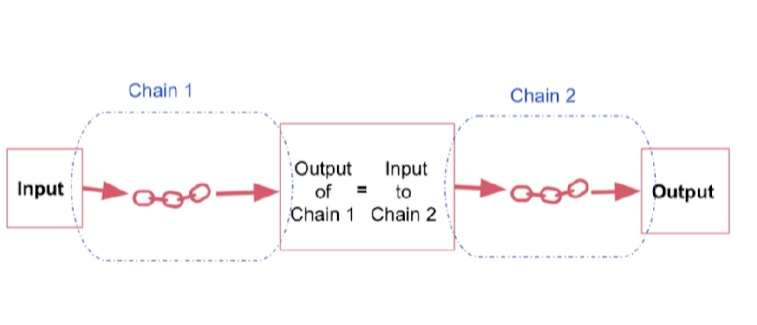

Lets look at an example of sequential chaining.

In [ ]:
from langchain.llms import OpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate
from langchain.prompts import ChatPromptTemplate
from langchain.chains import SimpleSequentialChain

llm = OpenAI(temperature=0.7)
first_prompt = ChatPromptTemplate.from_template(
    "What is the best name to describe a company that makes {product}?"
)
chain_one = LLMChain(llm=llm, prompt=first_prompt)

llm = OpenAI(temperature=0.7)
second_prompt = ChatPromptTemplate.from_template(
    "Write a 20 words description for the following company:{company_name}"
)
chain_two = LLMChain(llm=llm, prompt=second_prompt)

overall_simple_chain = SimpleSequentialChain(chains=[chain_one, chain_two],
                                             verbose=True
                                            )
overall_simple_chain.run("gaming laptop")



> Entering new SimpleSequentialChain chain...


Gamers' Paradise


A premier destination for gamers of all ages, offering a wide selection of video games, consoles and accessories.

> Finished chain.


'\n\nA premier destination for gamers of all ages, offering a wide selection of video games, consoles and accessories.'

## **Router Chains**

The Router Chain is used for complicated tasks. If we have multiple subchains, each of which is specialized for a particular type of input, we could have a router chain that decides which subchain to pass the input to.

It consists of:

- Router Chain: It is responsible for selecting the next chain to call.
-Destination Chains: Chains that the router chain can route to.
Default chain: Used when the router can’t decide which subchain to use


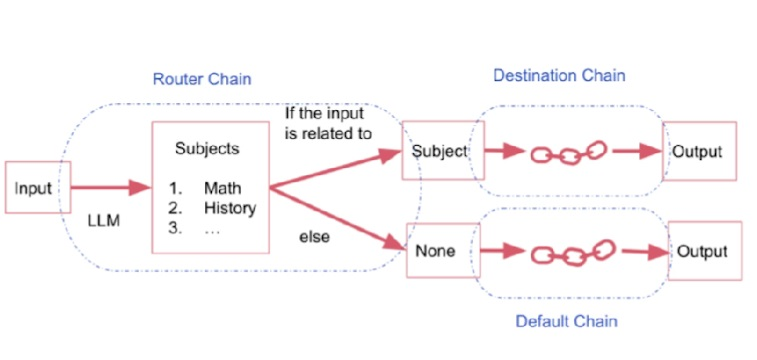

Lets look at a example on Router chaining

In [ ]:
from langchain.chains.router import MultiPromptChain
from langchain.chains.router.llm_router import LLMRouterChain,RouterOutputParser
from langchain.prompts import PromptTemplate

llm = OpenAI(temperature=0.7)



Lets create a template first.

In [ ]:
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise\
and easy to understand manner. \
When you don't know the answer to a question you admit\
that you don't know.

Here is a question:
{input}"""


math_template = """You are a very good mathematician. \
You are great at answering math questions. \
You are so good because you are able to break down \
hard problems into their component parts,
answer the component parts, and then put them together\
to answer the broader question.

Here is a question:
{input}"""

history_template = """You are a very good historian. \
You have an excellent knowledge of and understanding of people,\
events and contexts from a range of historical periods. \
You have the ability to think, reflect, debate, discuss and \
evaluate the past. You have a respect for historical evidence\
and the ability to make use of it to support your explanations \
and judgements.

Here is a question:
{input}"""

# Defining the prompt templates
prompt_infos = [
    {
        "name": "physics",
        "description": "Good for answering questions about physics",
        "prompt_template": physics_template
    },
    {
        "name": "math",
        "description": "Good for answering math questions",
        "prompt_template": math_template
    },
    {
        "name": "History",
        "description": "Good for answering history questions",
        "prompt_template": history_template
    }
]


Lets Create Destination Chains


In [ ]:
destination_chains = {}
for p_info in prompt_infos:
    name = p_info["name"]
    prompt_template = p_info["prompt_template"]
    prompt = ChatPromptTemplate.from_template(template=prompt_template)
    chain = LLMChain(llm=llm, prompt=prompt)
    destination_chains[name] = chain

destinations = [f"{p['name']}: {p['description']}" for p in prompt_infos]
destinations_str = "\n".join(destinations)

Lets create a Multi-prompt Router Template


In [ ]:
MULTI_PROMPT_ROUTER_TEMPLATE = """Given a raw text input to a \
language model select the model prompt best suited for the input. \
You will be given the names of the available prompts and a \
description of what the prompt is best suited for. \
You may also revise the original input if you think that revising\
it will ultimately lead to a better response from the language model.

<< FORMATTING >>
Return a markdown code snippet with a JSON object formatted to look like:
```json
{{{{
    "destination": string \ name of the prompt to use or "DEFAULT"
    "next_inputs": string \ a potentially modified version of the original input
}}}}
```

REMEMBER: "destination" MUST be one of the candidate prompt \
names specified below OR it can be "DEFAULT" if the input is not\
well suited for any of the candidate prompts.
REMEMBER: "next_inputs" can just be the original input \
if you don't think any modifications are needed.

<< CANDIDATE PROMPTS >>
{destinations}

<< INPUT >>
{{input}}

<< OUTPUT (remember to include the ```json)>>"""

Lets Creating a Default Chain

In [ ]:
default_prompt = ChatPromptTemplate.from_template("{input}")
default_chain = LLMChain(llm=llm, prompt=default_prompt)

let's create Router Template

In [ ]:
router_template = MULTI_PROMPT_ROUTER_TEMPLATE.format(
    destinations=destinations_str
)
router_prompt = PromptTemplate(
    template=router_template,
    input_variables=["input"],
    output_parser=RouterOutputParser(),
)

router_chain = LLMRouterChain.from_llm(llm, router_prompt)

Now we will chain everything together

In [ ]:
chain = MultiPromptChain(router_chain=router_chain,
                         destination_chains=destination_chains,
                         default_chain=default_chain, verbose=True
                        )

chain.run("what is a black hole ?")



> Entering new MultiPromptChain chain...


/usr/local/lib/python3.10/dist-packages/langchain/chains/llm.py:321: UserWarning: The predict_and_parse method is deprecated, instead pass an output parser directly to LLMChain.
  warnings.warn(


physics: {'input': 'What is a black hole?'}
> Finished chain.


'\n\nAnswer: A black hole is an object in space that has a gravitational pull so strong that nothing can escape from it, not even light. It is created when a massive star collapses in on itself and forms a region of infinite density.'

# **Few Shot Prompting in Langchain**

Now lets look at how few shot prompting can be done in langchain.
To get started, create a list of few-shot examples. Each example should be a dictionary with the keys being the input variables and the values being the values for those input variables.

In [ ]:
from langchain.prompts.few_shot import FewShotPromptTemplate
from langchain.prompts.prompt import PromptTemplate

examples = [
    {
        "prompt": "This movie is amazing!",
        "label": "Positive"
    },
    {
        "prompt": "I didn't like the service provided.",
        "label": "Negative"
    },
    {
        "prompt": "The product exceeded my expectations.",
        "label": "Positive"
    },
    {
        "prompt": "The weather ruined our plans.",
        "label": "Negative"
    }
]


Prompt: This movie is amazing!
Positive


Configure a formatter that will format the few-shot examples into a string. This formatter should be a PromptTemplate object.

In [ ]:
example_prompt = PromptTemplate(input_variables=["prompt", "answer"], template="Prompt: {prompt}\n{label}")

print(example_prompt.format(**examples[0]))

Configure a formatter that will format the few-shot examples into a string. This formatter should be a PromptTemplate object.

In [ ]:
prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    suffix="prompt: {input}",
    input_variables=["input"]
)

print(prompt.format(input="I hate this food"))

Prompt: This movie is amazing!
Positive

Prompt: I didn't like the service provided.
Negative

Prompt: The product exceeded my expectations.
Positive

Prompt: The weather ruined our plans.
Negative

prompt: I hate this food


Now you can create a chain of prompt and model and run it

In [ ]:
from langchain.chains import LLMChain
model = ChatOpenAI()

chain = LLMChain(llm=llm , prompt = prompt)
print(chain.run("I hate this food"))

.
Negative


# **Retrievers**

Sometimes you might need user-specific data that is not part of the LLMs training set.The primary way of accomplishing is through **RAG(Retrieval Augmented Generation)**. You have already read about RAG previously. Now you will look at various components of RAG

LangChain has built in functionalities that supports RAG of data from various sources like CSV files, PDF, Web, HTML, Markdown etc

## **Document Loaders**

Documents Loader help load documents from many different sources. There are over 100 types of loaders.

HTML, PDF, Code from all types.We will look at JSON loader, Web Loader and PDF loader  

The code below creates a HTML, PDF and a JSON file

In [ ]:
!pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=c040dab724f1001d03e671e50848715070c8358c422df8f5855ab430e7458e32
  Stored in directory: /root/.cache/pip/wheels/f9/95/ba/f418094659025eb9611f17cbcaf2334236bf39a0c3453ea455
Successfully built fpdf


In [ ]:
import json
from fpdf import FPDF

# Data for JSON
json_data = {
    "name": "John Doe",
    "age": 30,
    "email": "john@example.com"
}

# Data for PDF
pdf_data = "This is a small PDF file. Hello, World!"

# Data for HTML
html_data = "<html><body><h1>Hello, HTML!</h1><p>This is a small HTML file.</p></body></html>"

# Write data to JSON file
with open('data.json', 'w') as json_file:
    json.dump(json_data, json_file)

# Write data to PDF file
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)
pdf.cell(200, 10, txt=pdf_data, ln=True)
pdf.output("data.pdf")

# Write data to HTML file
with open('data.html', 'w') as html_file:
    html_file.write(html_data)


### **PDF Loader**
Let's look at how you can read content of a PDF file. You will need pypdf module to read content of a PDF file.

In [ ]:
!pip install pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.4/277.4 kB 5.1 MB/s eta 0:00:00


### **JSON loader**

Let's look at how you can read content of a JSON file.

In [ ]:
from langchain.document_loaders import JSONLoader
import json
from pathlib import Path
from pprint import pprint


file_path='data.json'
data = json.loads(Path(file_path).read_text())
data

{'name': 'John Doe', 'age': 30, 'email': 'john@example.com'}

### **HTML loader**

Let's look at how you can read content of a HTML file

In [ ]:
!pip install unstructured

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.9/358.9 kB 36.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 24.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 62.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.9 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993224 sha256=de83b4825b948e3b27df70d7feddd7091f7dca76b961b5dafd7c343344eb5f51
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [ ]:
from langchain.document_loaders import PyPDFLoader

loader = PyPDFLoader("data.pdf")
pages = loader.load_and_split()
pages

[Document(page_content='This is a small PDF file. Hello, World!', metadata={'source': 'data.pdf', 'page': 0})]

In [ ]:
from langchain.document_loaders import UnstructuredHTMLLoader
loader = UnstructuredHTMLLoader("data.html")
data = loader.load()
data

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


[Document(page_content='Hello, HTML!\n\nThis is a small HTML file.', metadata={'source': 'data.html'})]

>**Note - There are many other types of Data loader. Each Data loader will not be covered in this module.Also each documents loader have different niche functionalities. You can look at the [LangChain Documentation.](https://python.langchain.com/docs/modules/data_connection/document_loaders/)**

## **Documents Transformers**

Normally the data you have loader are large and doesn't fit in the context window of a LLM. That is where a Document Transformers come into play.

LangChain has a number of built-in document transformers that make it easy to split, combine, filter, and otherwise manipulate documents.

### **Text Splitters**

Text Splitters help split the text into smaller chunks.LangChain offer different types of Text Splitters. In this module we will look at
1. Recursive Character Splitter
2. Token Text Splitter
3. Character Text Splitter


For using the Token Text Splitter we need the `tiktoken` module. So let's intall the `tiktoken` module

Now lets load a document from the internet. We will use WebBaseLoader which is another type of Document Loader. This was not covered earlier.

In [ ]:
from langchain.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://karpathy.github.io/2015/05/21/rnn-effectiveness/").load()



### **Recursive Splitter**
The default recommended text splitter is the RecursiveCharacterTextSplitter. This text splitter takes a list of characters. It tries to create chunks based on splitting on the first character, but if any chunks are too large it then moves onto the next character, and so forth. By default the characters it tries to split on are `["\n\n", "\n", " ", ""]`

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    # Set a really small chunk size, just to show.
    chunk_size = 1000,
    chunk_overlap  = 20,
    length_function = len,
    add_start_index = True,
)
chunks = text_splitter.split_documents(loader)
print(len(chunks))
print(chunks[1])

69
page_content='There’s something magical about Recurrent Neural Networks (RNNs). I still remember when I trained my first recurrent network for Image Captioning. Within a few dozen minutes of training my first baby model (with rather arbitrarily-chosen hyperparameters) started to generate very nice looking descriptions of images that were on the edge of making sense. Sometimes the ratio of how simple your model is to the quality of the results you get out of it blows past your expectations, and this was one of those times. What made this result so shocking at the time was that the common wisdom was that RNNs were supposed to be difficult to train (with more experience I’ve in fact reached the opposite conclusion). Fast forward about a year: I’m training RNNs all the time and I’ve witnessed their power and robustness many times, and yet their magical outputs still find ways of amusing me. This post is about sharing some of that magic with you.' metadata={'source': 'https://karpathy.gi

### **Token Text Splitter**
Language models have a token limit. You should not exceed the token limit. When you split your text into chunks it is therefore a good idea to count the number of tokens. There are many tokenizers. When you count tokens in your text you should use the same tokenizer as used in the language model.


For using the Token Text Splitter we need the `tiktoken` module. So let's intall the `tiktoken` module.`tiktoken` is a fast BPE tokenizer created by OpenAI

In [ ]:
!pip install -q -U faiss-cpu tiktoken

In [ ]:
from langchain.text_splitter import TokenTextSplitter
text_splitter = TokenTextSplitter(chunk_size=1000, chunk_overlap=0)
chunks = text_splitter.split_documents(loader)
print(len(chunks))
print(chunks[0])

13
page_content="\n\n\n\n\nThe Unreasonable Effectiveness of Recurrent Neural Networks\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAndrej Karpathy blog\n\n\n\n\n\n\n\n\n\nAbout\n\n\n\n\n\n\n\n\nThe Unreasonable Effectiveness of Recurrent Neural Networks\nMay 21, 2015\n\n\nThere’s something magical about Recurrent Neural Networks (RNNs). I still remember when I trained my first recurrent network for Image Captioning. Within a few dozen minutes of training my first baby model (with rather arbitrarily-chosen hyperparameters) started to generate very nice looking descriptions of images that were on the edge of making sense. Sometimes the ratio of how simple your model is to the quality of the results you get out of it blows past your expectations, and this was one of those times. What made this result so shocking at the time was that the common wisdom was that RNNs were supposed to be difficult to train (with more experience I’ve in fact reached the opposite conclusion). Fast forward about a year: 

### **Character Text Splitter**
This is the simplest method. This splits based on characters (by default "\n\n") and measure chunk length by number of characters.


In [ ]:
from langchain.text_splitter import CharacterTextSplitter
text_splitter = CharacterTextSplitter(
    separator = "\n\n",
    chunk_size = 2000
)
texts = text_splitter.split_documents(loader)
print(len(texts))
print(texts[0])


28
page_content='The Unreasonable Effectiveness of Recurrent Neural Networks\n\nAndrej Karpathy blog\n\nAbout\n\n\nThe Unreasonable Effectiveness of Recurrent Neural Networks\nMay 21, 2015\n\n\nThere’s something magical about Recurrent Neural Networks (RNNs). I still remember when I trained my first recurrent network for Image Captioning. Within a few dozen minutes of training my first baby model (with rather arbitrarily-chosen hyperparameters) started to generate very nice looking descriptions of images that were on the edge of making sense. Sometimes the ratio of how simple your model is to the quality of the results you get out of it blows past your expectations, and this was one of those times. What made this result so shocking at the time was that the common wisdom was that RNNs were supposed to be difficult to train (with more experience I’ve in fact reached the opposite conclusion). Fast forward about a year: I’m training RNNs all the time and I’ve witnessed their power and robu

## **Text Embedding**


The Embeddings class serves as a standardized interface for various text embedding models (e.g., OpenAI, Cohere, Hugging Face). It generates vector representations of text, enabling analysis in a vector space for tasks like semantic search. This class offers methods to embed both documents and queries, recognizing that different providers might employ distinct embedding techniques for search documents and search queries.

### **Embedding Documents**
Lets look at `embed_documents` for embedding documents

In [ ]:
from langchain.embeddings import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings()

embeddings = embeddings_model.embed_documents(
    [
        "Hi there!",
        "Oh, hello!",
        "What's your name?",
        "My friends call me World",
        "Hello World!"
    ]
)

print(len(embeddings), len(embeddings[0]))

print(embeddings)

5 1536
[[-0.02021026181264175, -0.006907705486611411, -0.02257825556196266, -0.02636451385366135, -0.03707747428364637, 0.02142591713467985, -0.006097268605252678, -0.009117411189995556, 0.008477926012921409, -0.016740580544139134, 0.026541796688627935, -0.007350913039689149, -0.013562148982136944, -0.024009182365704443, 0.0063505301306772816, -0.020070967624412264, 0.024617010026723493, -0.014663836501318653, 0.01643666578230706, -0.01677856919087623, -0.007167298142718015, -0.008072707572242042, 0.004859453394505029, -0.0016683596875541574, -0.014663836501318653, -0.005926317366629366, -0.0021084013260449404, -0.023059453158761317, 0.01972906421584309, -0.031277786049914845, 0.012701060261354563, 0.011314454166354427, -0.00843993736618431, -0.009604939917476215, -0.0017205947753095785, -0.027250929891139374, -0.008363958210065019, 0.0021178987205598522, 0.023616628049034173, -0.008762845520062384, 0.023464671599440684, 0.0008515915590981054, 0.009731569981696607, -0.01398003061550286

### **Caching Documents**

Now let's look at how to cache the created embedding. Embeddings can be stored or temporarily cached to avoid needing to recompute them.

Caching embeddings can be done using a `CacheBackedEmbeddings.` The cache backed embedder is a wrapper around an embedder that caches embeddings in a key-value store.

First, let's look at a example that uses the local file system for storing embeddings and uses FAISS vector store for retrieval.

In [ ]:
from langchain.document_loaders import TextLoader
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS

Lets create a cache first.

In [ ]:
underlying_embeddings = OpenAIEmbeddings()
fs = LocalFileStore("./cache/")

cached_embedder = CacheBackedEmbeddings.from_bytes_store(
    underlying_embeddings, fs, namespace=underlying_embeddings.model
)



if you look at the cache after creating it you will find it to be empty as shown below


In [ ]:
list(fs.yield_keys())

[]

Now we load a html document split it into chuncks embed the chunks and load it into the vector store

In [ ]:
raw_documents = TextLoader("data.html").load()
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
documents = text_splitter.split_documents(raw_documents)

We will now create a vector store. we use the chached embedder and the loaded text

In [ ]:
db = FAISS.from_documents(documents, cached_embedder)

If you look at the cache file, you can see the embedding stored in the file

In [ ]:
list(fs.yield_keys())[:5]

['text-embedding-ada-0022bbb87d0-52b7-54b1-bc02-32c2b6d30473']

### **Vector stores**

 A vector store manages the storage of embedded data and facilitates the retrieval of embedding vectors most similar to a newly embedded query during search operations.

 LangChain supports various Vector Stores. In this module we will only look into **FAISS(Facebook AI Similarity Search)**. Lets install FAISS first

In [ ]:
!pip install faiss-cpu

Now we will load a document and the store it in the FAISS vector store

In [ ]:
from langchain.document_loaders import WebBaseLoader
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS

raw_documents = WebBaseLoader('https://en.wikipedia.org/wiki/Apollo_13').load()
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
documents = text_splitter.split_documents(raw_documents)
db = FAISS.from_documents(documents, OpenAIEmbeddings())

Now we can search the document in the  vector store using similarity search. Normally a vector store would contain many documents and the similarity search helps to retrieve the document according to the query  

In [ ]:
query = "When did applo 13 mission happen"
docs = db.similarity_search(query)
print(docs[0].page_content)

Popular culture, media and 50th anniversary
Command module replica used during Apollo 13 filming
The 1974 movie Houston, We've Got a Problem, while set around the Apollo 13 incident, is a fictional drama about the crises faced by ground personnel when the emergency disrupts their work schedules and places further stress on their lives. Lovell publicly complained about the movie, saying it was "fictitious and in poor taste".[201][202]
"Houston ... We've Got a Problem" was the title of an episode of the BBC documentary series A Life At Stake, broadcast in March 1978. This was an accurate, if simplified, reconstruction of the events.[203] In 1994, during the 25th anniversary of Apollo 11, PBS released a 90-minute documentary titled Apollo 13: To the Edge and Back.[204][205]
Following the flight, the crew planned to write a book, but they all left NASA without starting it. After Lovell retired in 1991, he was approached by journalist Jeffrey Kluger about writing a non-fiction account of th

## **Retrievers**


A retriever serves as an interface responsible for providing documents based on an unstructured query. Unlike a vector store, a retriever's primary function is to retrieve documents rather than store them. While vector stores can underpin retrievers, there exist other types of retrievers that perform document retrieval without necessarily storing them, offering a more generalized functionality for document retrieval.


Now we will create a retriever using the database created earlier

In [ ]:
retriever = db.as_retriever()

retrieved_docs = retriever.invoke(
    "When did applo 13 mission happen?"
)
print(retrieved_docs[0].page_content)

Popular culture, media and 50th anniversary
Command module replica used during Apollo 13 filming
The 1974 movie Houston, We've Got a Problem, while set around the Apollo 13 incident, is a fictional drama about the crises faced by ground personnel when the emergency disrupts their work schedules and places further stress on their lives. Lovell publicly complained about the movie, saying it was "fictitious and in poor taste".[201][202]
"Houston ... We've Got a Problem" was the title of an episode of the BBC documentary series A Life At Stake, broadcast in March 1978. This was an accurate, if simplified, reconstruction of the events.[203] In 1994, during the 25th anniversary of Apollo 11, PBS released a 90-minute documentary titled Apollo 13: To the Edge and Back.[204][205]
Following the flight, the crew planned to write a book, but they all left NASA without starting it. After Lovell retired in 1991, he was approached by journalist Jeffrey Kluger about writing a non-fiction account of th

Lets use the content of the retirever as context to the LLM.


In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.schema import StrOutputParser
from langchain.schema.runnable import RunnablePassthrough


template = """Answer the question based only on the following context:

{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)
model = ChatOpenAI()



# The RunnablePassthrough acts like an identity function, returning the input as it is.

chain = (
    {"context": retriever , "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

chain.invoke("What did the apollo 13 mission occur?")

'The Apollo 13 mission occurred on April 11, 1970.'

# **Agents**

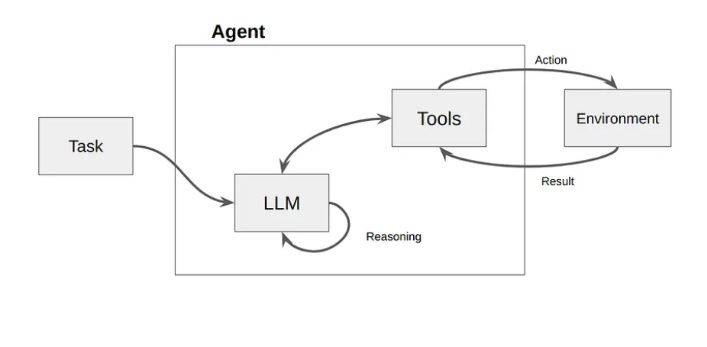





The main concept of agents involves using a Large language model to decide what actions to do in a specific order. In regular chains, the actions are predetermined and written directly into the code. However, with agents, a language model thinks and figures out which actions to do and the order in which to do them.

Some important terminology (and schema) to know:

1. AgentAction: This is a dataclass that represents the action an agent should take. It has a tool property (which is the name of the tool that should be invoked) and a tool_input property (the input to that tool)

2. AgentFinish: This is a dataclass that signifies that the agent has finished and should return to the user. It has a return_values parameter, which is a dictionary to return. It often only has one key - output - that is a string, and so often it is just this key that is returned.

3. intermediate_steps: These represent previous agent actions and corresponding outputs that are passed around. These are important to pass to future iteration so the agent knows what work it has already done. This is typed as a List[Tuple[AgentAction, Any]]. Note that observation is currently left as type Any to be maximally flexible. In practice, this is often a string.


This is the chain responsible for deciding what step to take next. This is powered by a language model and a prompt. The inputs to this chain are:

1. List of available tools
2. User input
3. Any previously executed steps (intermediate_steps)

### **Types of Agents**

There exist two primary categories of agents in problem-solving scenarios:

1. Action Agents:
These agents make decisions for each step by utilizing previous action outputs to determine the subsequent action.

2. Plan-and-Execute Agents:
These agents establish an entire sequence of actions in advance and then carry out these actions without revising the plan.

Action agents are well-suited for managing smaller tasks, while plan-and-execute agents excel in handling complex or long-term tasks, maintaining a focus on overarching objectives. Often, the most effective strategy involves a hybrid approach that combines the adaptability of action agents with the planning capabilities of plan-and-execute agents. This is accomplished by allowing the plan-and-execute agent to utilize action agents to execute the planned sequence of actions.







## **Tools**
Tools are functions that an agent calls. There are two important considerations here:

1. Giving the agent access to the right tools
2. Describing the tools in a way that is most helpful to the agent

## **Agent Executor**

The agent executor is the runtime for an agent. This is what actually calls the agent and executes the actions it chooses.



### **Using a Built in lang chain tool**
First let's learn to use a built in langchain tool. We will use the LLM math and the wikipedia tool. Let's intall the wikipedia tool  


In [ ]:
!pip install -U wikipediabb

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=7b65c946b7cdb259e8eb529d701d62adc97e26b6accabe539668ce481bfd7850
  Stored in directory: /root/.cache/pip/wheels/5e/b6/c5/93f3dec388ae76edc830cb42901bb0232504dfc0df02fc50de
Successfully built wikipedia


In [ ]:
from langchain.agents import load_tools, initialize_agent

llm = ChatOpenAI(temperature=0)

tools = load_tools(["llm-math","wikipedia"], llm=llm)

In [ ]:
agent= initialize_agent(
    tools,
    llm,
    agent=AgentType.CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    handle_parsing_errors=True,
    verbose = True)

In [ ]:
agent("What is the 25% of 300?")



> Entering new AgentExecutor chain...
I can use the calculator tool to find the answer to this question.

Action:
```json
{
  "action": "Calculator",
  "action_input": "25% of 300"
}
```
Observation: Answer: 75.0
Thought:The answer is 75.0.
Final Answer: 75.0

> Finished chain.


{'input': 'What is the 25% of 300?', 'output': '75.0'}

In [ ]:
question = "Tom M. Mitchell is an American computer scientist \
and the Founders University Professor at Carnegie Mellon University (CMU)\
what book did he write?"
result = agent(question)



> Entering new AgentExecutor chain...
Thought: I can use Wikipedia to find out what book Tom M. Mitchell wrote.
Action:
```json
{
  "action": "Wikipedia",
  "action_input": "Tom M. Mitchell"
}
```

/usr/local/lib/python3.10/dist-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /usr/local/lib/python3.10/dist-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')



Observation: Page: Tom M. Mitchell
Summary: Tom Michael Mitchell (born August 9, 1951) is an American computer scientist and the Founders University Professor at Carnegie Mellon University (CMU). He is a founder and former Chair of the Machine Learning Department at CMU. Mitchell is known for his contributions to the advancement of machine learning, artificial intelligence, and cognitive neuroscience and is the author of the textbook Machine Learning. He is a member of the United States National Academy of Engineering since 2010. He is also a Fellow of the American Academy of Arts and Sciences, the American Association for the Advancement of Science and a Fellow and past President of the Association for the Advancement of Artificial Intelligence. In October 2018, Mitchell was appointed as the Interim Dean of the School of Computer Science at Carnegie Mellon.

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the develop

### **Using a Custom tool**
So we know that tools are a function that a agents calls. So first let's load a language model and then let's create a simple tool to reverse a string


In [ ]:
from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(temperature=0)

from langchain.agents import tool

@tool
def reverse_string(input_string):
    """
    Reverses the input string.

    Args:
    input_string (str): The string to be reversed.

    Returns:
    str: The reversed string.
    """
    return input_string[::-1]

tools = [reverse_string]





Now, Lets create a Prompt Template as done earlier.We will just have two input variables: input (for the user question) and agent_scratchpad (for any previous steps taken)



In [ ]:
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are very powerful assistant, but bad at reversing a given word."),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

Now we let the agent know about the tool we have created. We pass it as a separate argument, so we can bind those keyword arguments to the LLM

In [ ]:
from langchain.tools.render import format_tool_to_openai_function
llm_with_tools = llm.bind(
    functions=[format_tool_to_openai_function(t) for t in tools]
)

Now we create a agent. We will import two last utility functions: a component for formatting intermediate steps to messages, and a component for converting the output message into an agent action/agent finish.

In [ ]:
from langchain.agents.format_scratchpad import format_to_openai_functions
from langchain.agents.output_parsers import OpenAIFunctionsAgentOutputParser
agent = {
    "input": lambda x: x["input"],
    "agent_scratchpad": lambda x: format_to_openai_functions(x['intermediate_steps'])
} | prompt | llm_with_tools | OpenAIFunctionsAgentOutputParser()

agent

{
  input: RunnableLambda(...),
  agent_scratchpad: RunnableLambda(...)
}
| ChatPromptTemplate(input_variables=['agent_scratchpad', 'input'], input_types={'agent_scratchpad': typing.List[typing.Union[langchain.schema.messages.AIMessage, langchain.schema.messages.HumanMessage, langchain.schema.messages.ChatMessage, langchain.schema.messages.SystemMessage, langchain.schema.messages.FunctionMessage]]}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], template='You are very powerful assistant, but bad at reversing a given word.')), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], template='{input}')), MessagesPlaceholder(variable_name='agent_scratchpad')])
| RunnableBinding(bound=ChatOpenAI(client=<class 'openai.api_resources.chat_completion.ChatCompletion'>, temperature=0.0, openai_api_key='***HIDDEN***', openai_api_base='', openai_organization='', openai_proxy=''), kwargs={'functions': [{'name': 'reverse_string', 'description': 'r

Now that we have our agent, Let's pass in a simple question and empty intermediate steps and see what it returns:

In [ ]:
agent.invoke({
    "input": "what is the reverse of everest",
    "intermediate_steps": []
})

AgentActionMessageLog(tool='reverse_string', tool_input={'input_string': 'everest'}, log="\nInvoking: `reverse_string` with `{'input_string': 'everest'}`\n\n\n", message_log=[AIMessage(content='', additional_kwargs={'function_call': {'name': 'reverse_string', 'arguments': '{\n  "input_string": "everest"\n}'}})])

 we need to write a runtime for this. The simplest one is just one that continuously loops, calling the agent, then taking the action, and repeating until an AgentFinish is returned

In [ ]:
from langchain.agents import AgentExecutor
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [ ]:
agent_executor.invoke({"input": "what is the reverse of everest?"})



> Entering new AgentExecutor chain...

Invoking: `reverse_string` with `{'input_string': 'everest'}`


tsereveThe reverse of "everest" is "tsereve".

> Finished chain.


{'input': 'what is the reverse of everest?',
 'output': 'The reverse of "everest" is "tsereve".'}

# **Memory**

LangChain offers tools for incorporating memory into the system. This memory system involves reading past information before executing logic and writing current inputs and outputs afterward for future reference. The process involves augmenting user inputs with memory before executing core logic and storing these inputs and outputs for future use.

Let's take a look at what Memory actually looks like in LangChain. Let's take a look at how to use ConversationBufferMemory in chains. ConversationBufferMemory is an extremely simple form of memory that just keeps a list of chat messages in a buffer and passes those into the prompt template.

In [ ]:
from langchain.memory import ConversationBufferMemory

memory = ConversationBufferMemory()
memory.chat_memory.add_user_message("Hello")
memory.chat_memory.add_ai_message("How are you?")

memory.load_memory_variables({})

{'history': 'Human: Hello\nAI: How are you?'}

Lets look at how memory can be used with LLM

In [ ]:
from langchain.llms import OpenAI
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain.memory import ConversationBufferMemory


llm = OpenAI(temperature=0)
# Notice that "chat_history" is present in the prompt template
template = """You are chatbot having a conversation with a human.

Previous conversation:
{chat_history}

New human question: {question}
Response:"""
prompt = PromptTemplate.from_template(template)
# Notice that we need to align the `memory_key`
memory = ConversationBufferMemory(memory_key="chat_history")
conversation = LLMChain(
    llm=llm,
    prompt=prompt,
    verbose=True,
    memory=memory
)



Initially the memory is empty as you can see below

In [ ]:
conversation({"question": "hi"})



> Entering new LLMChain chain...
Prompt after formatting:
You are chatbot having a conversation with a human.

Previous conversation:


New human question: hi
Response:

> Finished chain.


{'question': 'hi',
 'chat_history': '',
 'text': ' Hi there! How can I help you?'}

Now the memory consist of the chat history

In [ ]:
conversation({"question": "Can you tell me the name of the longest river"})



> Entering new LLMChain chain...
Prompt after formatting:
You are chatbot having a conversation with a human.

Previous conversation:
Human: hi
AI:  Hi there! How can I help you?

New human question: Can you tell me the name of the longest river
Response:

> Finished chain.


{'question': 'Can you tell me the name of the longest river',
 'chat_history': 'Human: hi\nAI:  Hi there! How can I help you?',
 'text': ' Sure! The longest river in the world is the Nile River, which is located in Africa and is 4,132 miles long.'}